In [12]:
import numpy as np
import pandas as pd

#%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import mplcursors

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [13]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/*/qtransform_features.parquet"))
RANDOM_STATE = 42

MONTH_ORDER = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6, "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}

In [14]:
if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}")

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

parquet_files = list(DATA_DIR.glob("*/*/qtransform_features.parquet"))
parquet_files.sort(key=lambda p: (int(p.parent.parent.name), MONTH_ORDER[p.parent.name]))

for file in parquet_files:
    print(f"Loading: {file}")

    df = pd.read_parquet(file)
    folder = file.parent
    
    year = int(folder.parent.name)
    month = folder.name.lower()

    image_paths = [str(folder / f"qtransform_{i:06d}.pdf") for i in range(len(df))]
    missing_images = [path for path in image_paths if not Path(path).exists()]

    if missing_images:
        raise FileNotFoundError(f"{len(missing_images)} PDF files are missing in {folder}. First missing file: {missing_images[0]}")

    df["image_path"] = image_paths
    df["source_file"] = file.name
    df["source_path"] = str(file)

    df["year"] = year
    df["month"] = month

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print(f"Feature matrix: X.shape = {X.shape}")

Found 48 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_par

In [15]:
X = df_all[feature_columns].to_numpy(dtype=np.float64)
X_norm = X / 40

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 20

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=40,early_exaggeration=500,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='manhattan')
X_tsne = tsne.fit_transform(X_pca)

Scaled matrix: (30704, 1230)
PCA components: 20
Explained variance: 0.4457


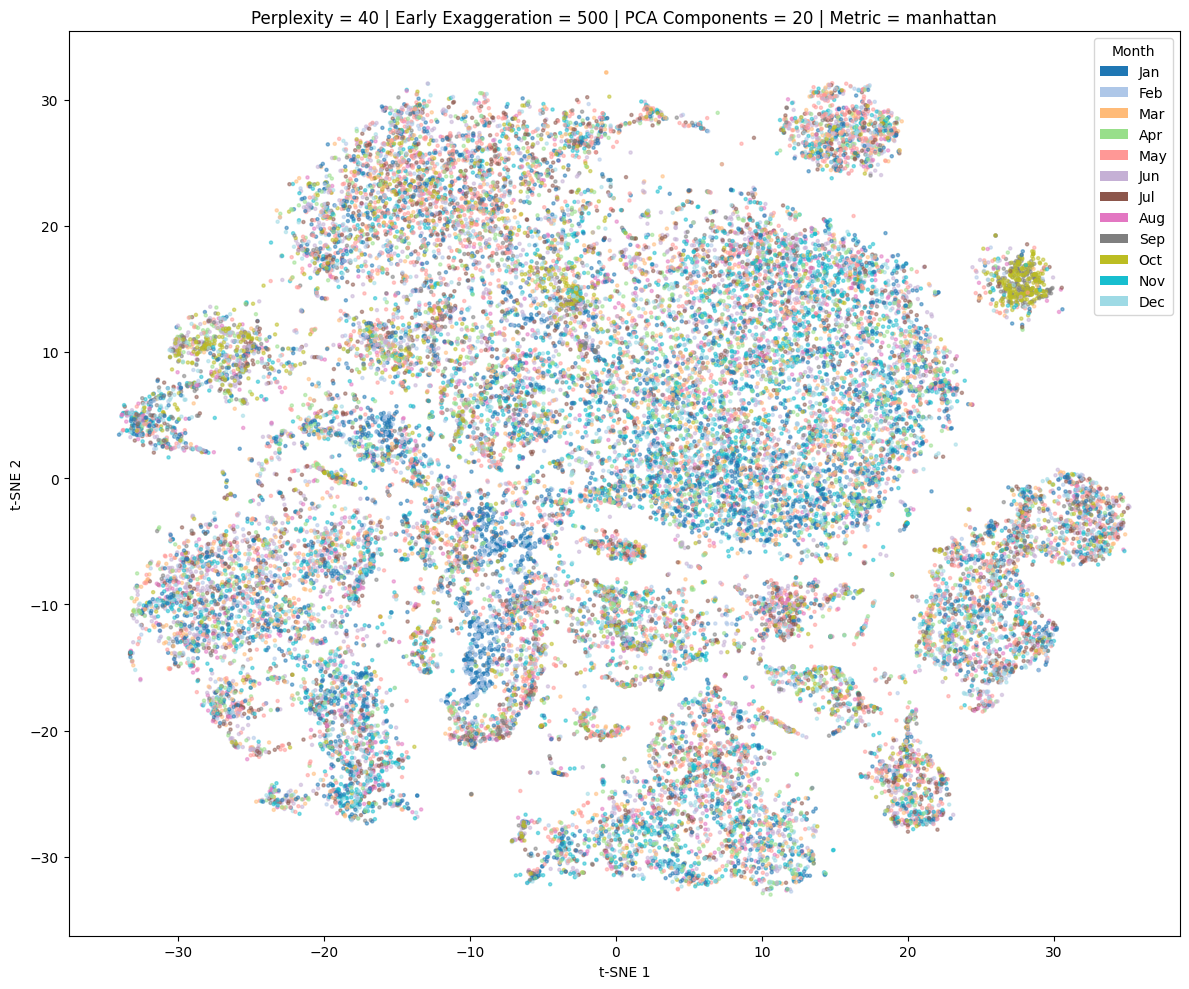

In [16]:
MONTH_NAMES = {"jan": "Jan","feb": "Feb","mar": "Mar","apr": "Apr","may": "May","jun": "Jun",
               "jul": "Jul","ago": "Aug","sep": "Sep","oct": "Oct","nov": "Nov","dec": "Dec"}

MONTHS = list(MONTH_ORDER.keys())
month_to_index = {month: i for i, month in enumerate(MONTHS)}
month_indices = df_all["month"].map(month_to_index).to_numpy()

cmap = plt.get_cmap("tab20", 12)
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0],X_tsne[:, 1],c=month_indices,cmap=cmap,vmin=-0.5,vmax=11.5,s=5,alpha=0.5)

legend_handles = [Patch(facecolor=cmap(i),label=MONTH_NAMES[month]) for i, month in enumerate(MONTHS)]
ax.legend(handles=legend_handles,title="Month",loc="best",markerscale=2,frameon=True)
ax.set_title(f"Perplexity = 40 | Early Exaggeration = 500 | PCA Components = {PCA_COMPONENTS} | Metric = manhattan")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

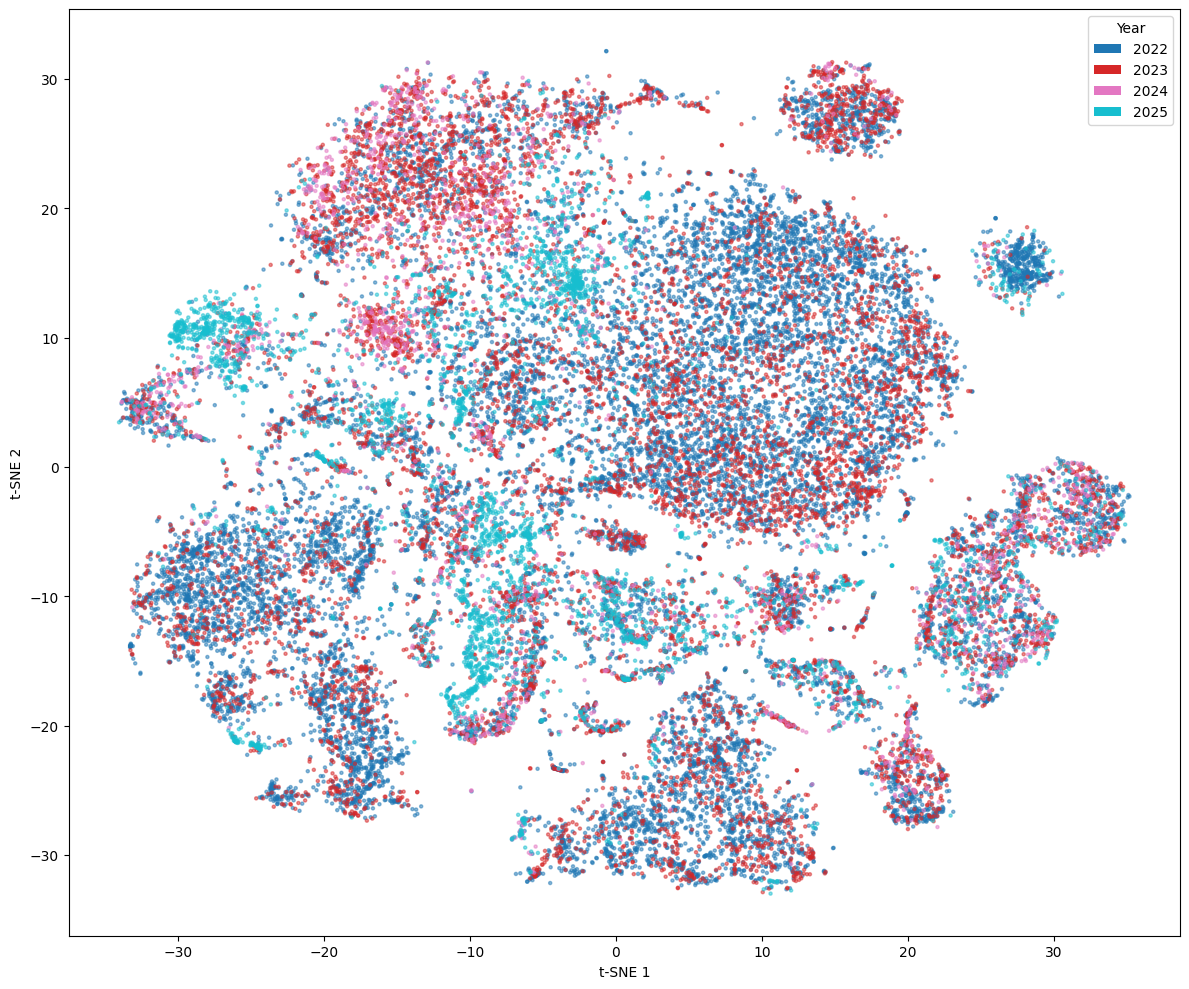

In [19]:
years = sorted(df_all["year"].unique())
year_to_index = {year: i for i, year in enumerate(years)}
year_indices = df_all["year"].map(year_to_index).to_numpy()

cmap = plt.get_cmap("tab10", len(years))
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0],X_tsne[:, 1],c=year_indices,cmap=cmap,vmin=-0.5,vmax=len(years) - 0.5,s=5,alpha=0.5)
legend_handles = [Patch(facecolor=cmap(i), label=str(year))for i, year in enumerate(years)]
ax.legend(handles=legend_handles,title="Year",loc="best",markerscale=2)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

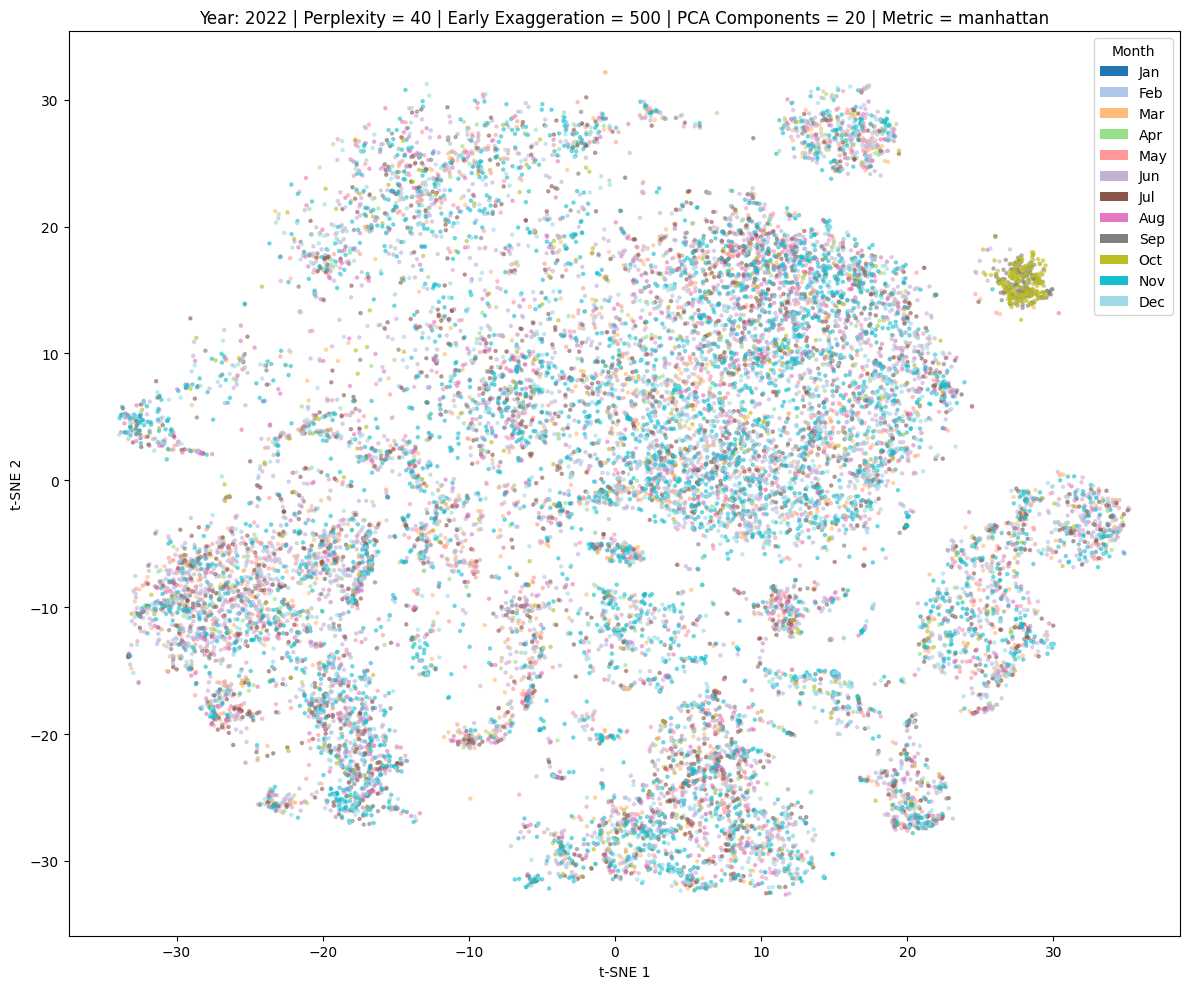

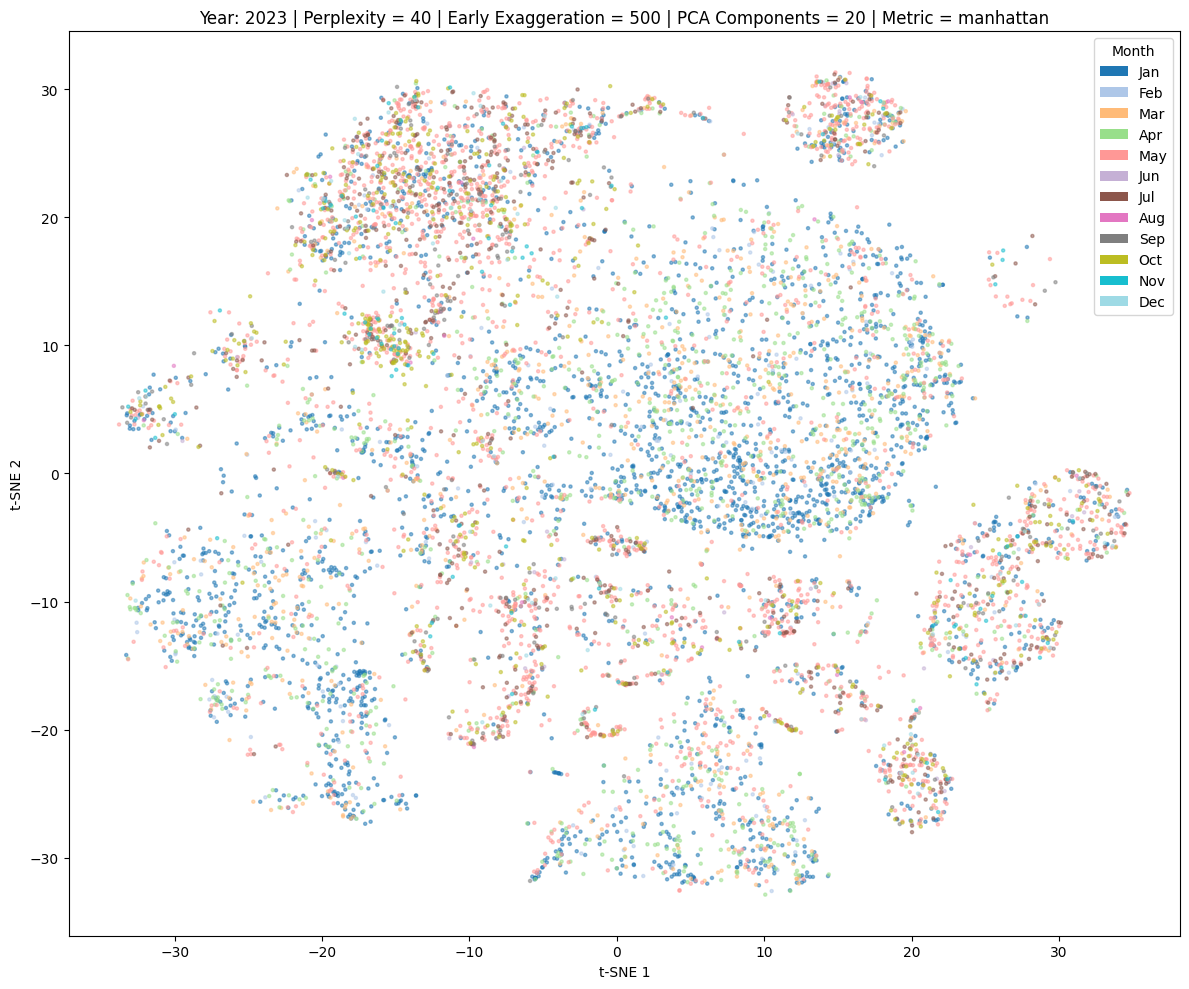

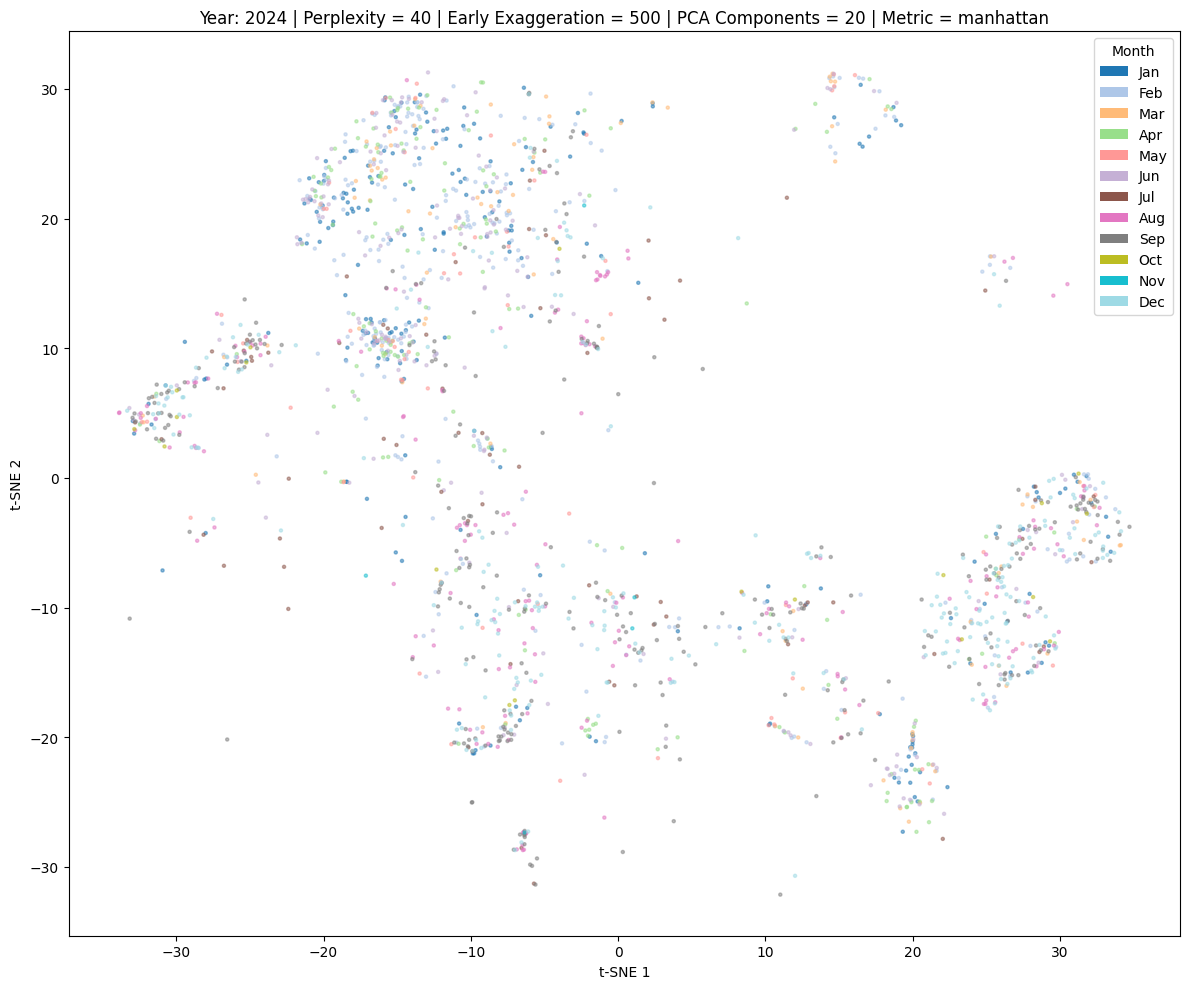

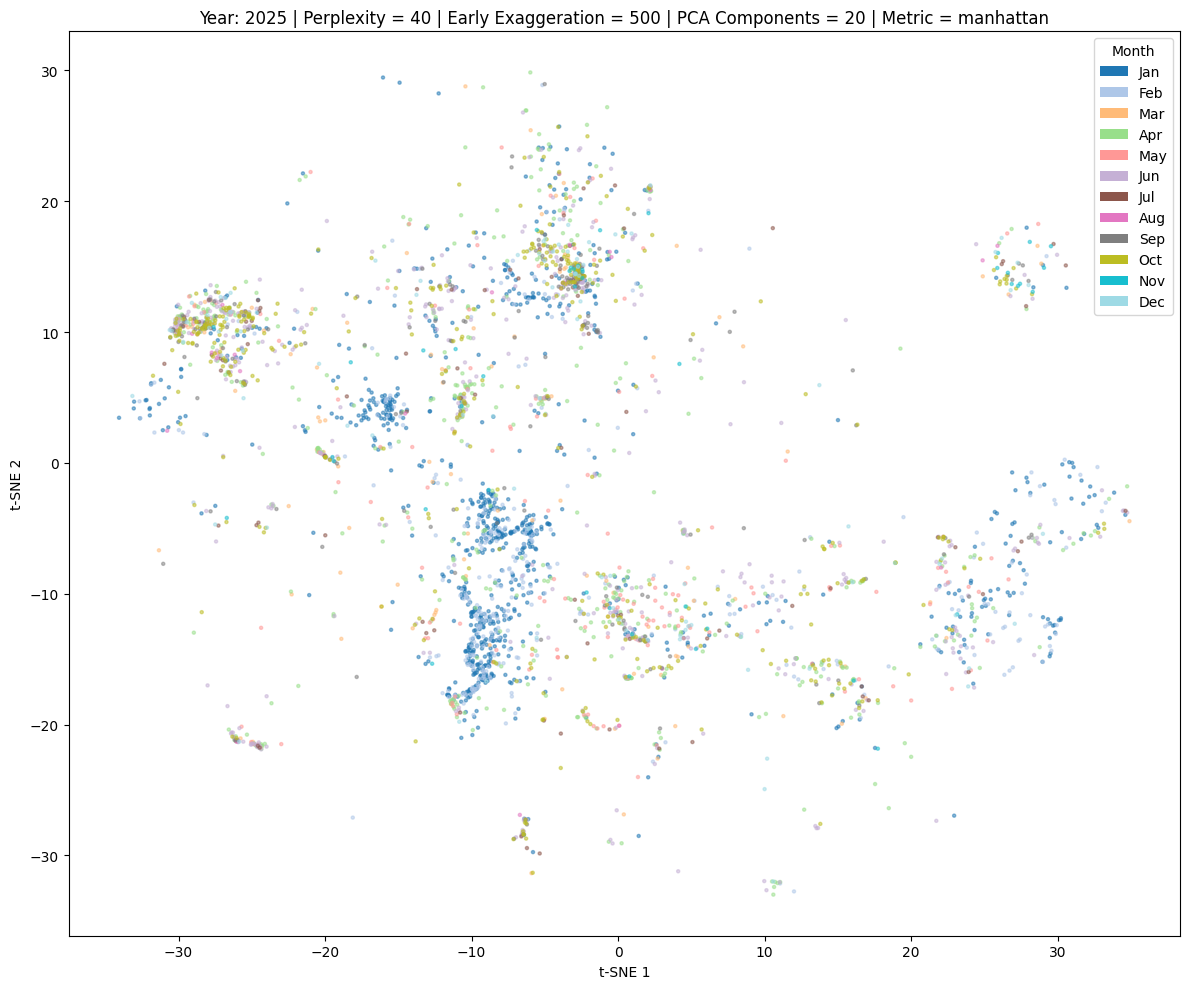

In [20]:
for year in years:
    year_mask = df_all["year"] == year
    X_tsne_year = X_tsne[year_mask]
    month_indices_year = month_indices[year_mask]

    cmap = plt.get_cmap("tab20", 12)
    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(X_tsne_year[:, 0],X_tsne_year[:, 1],c=month_indices_year,cmap=cmap,vmin=-0.5,vmax=11.5,s=5,alpha=0.5)

    legend_handles = [Patch(facecolor=cmap(i),label=MONTH_NAMES[month]) for i, month in enumerate(MONTHS)]
    ax.legend(handles=legend_handles,title="Month",loc="best",markerscale=2,frameon=True)
    ax.set_title(f"Year: {year} | Perplexity = 40 | Early Exaggeration = 500 | PCA Components = {PCA_COMPONENTS} | Metric = manhattan")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()

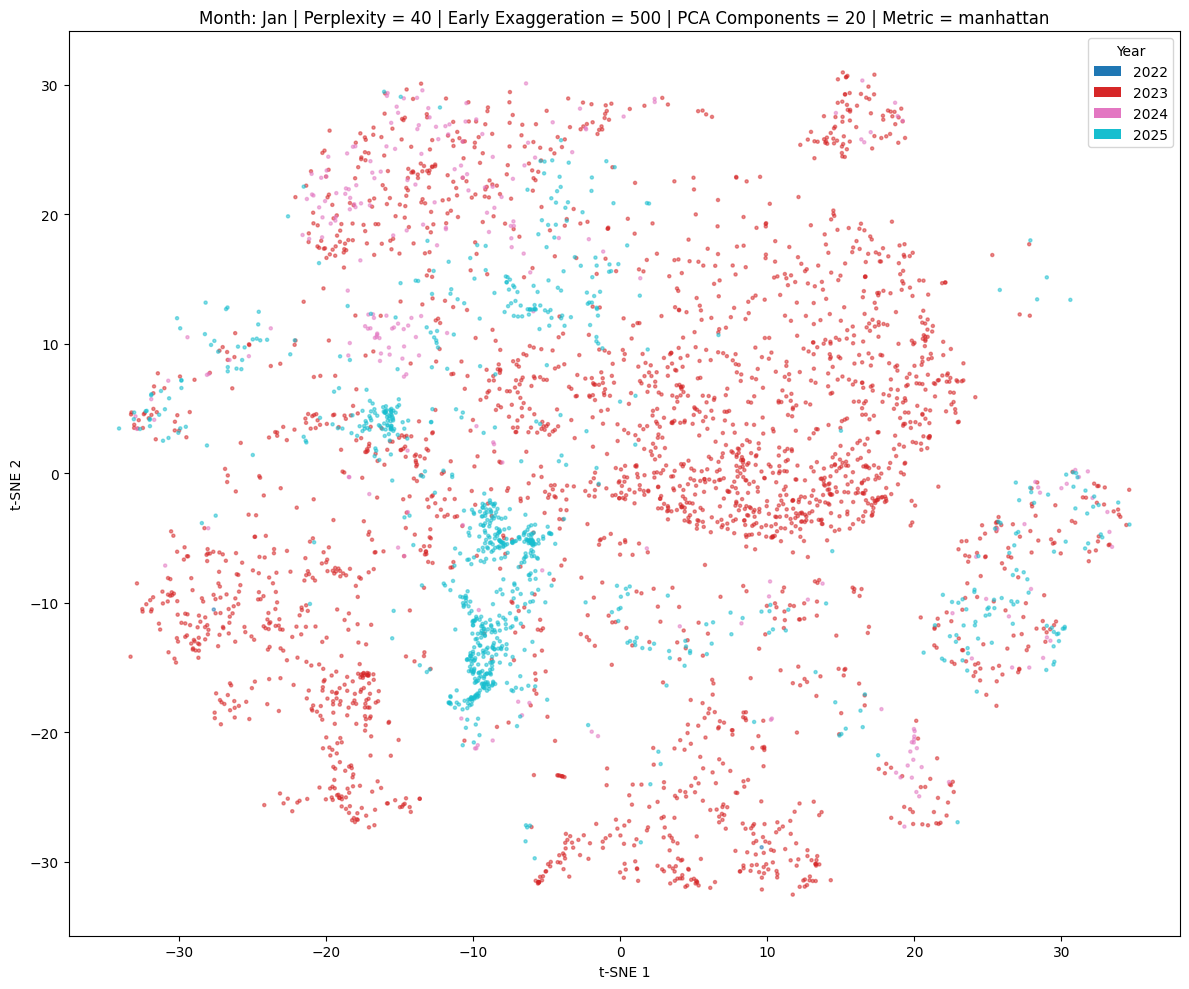

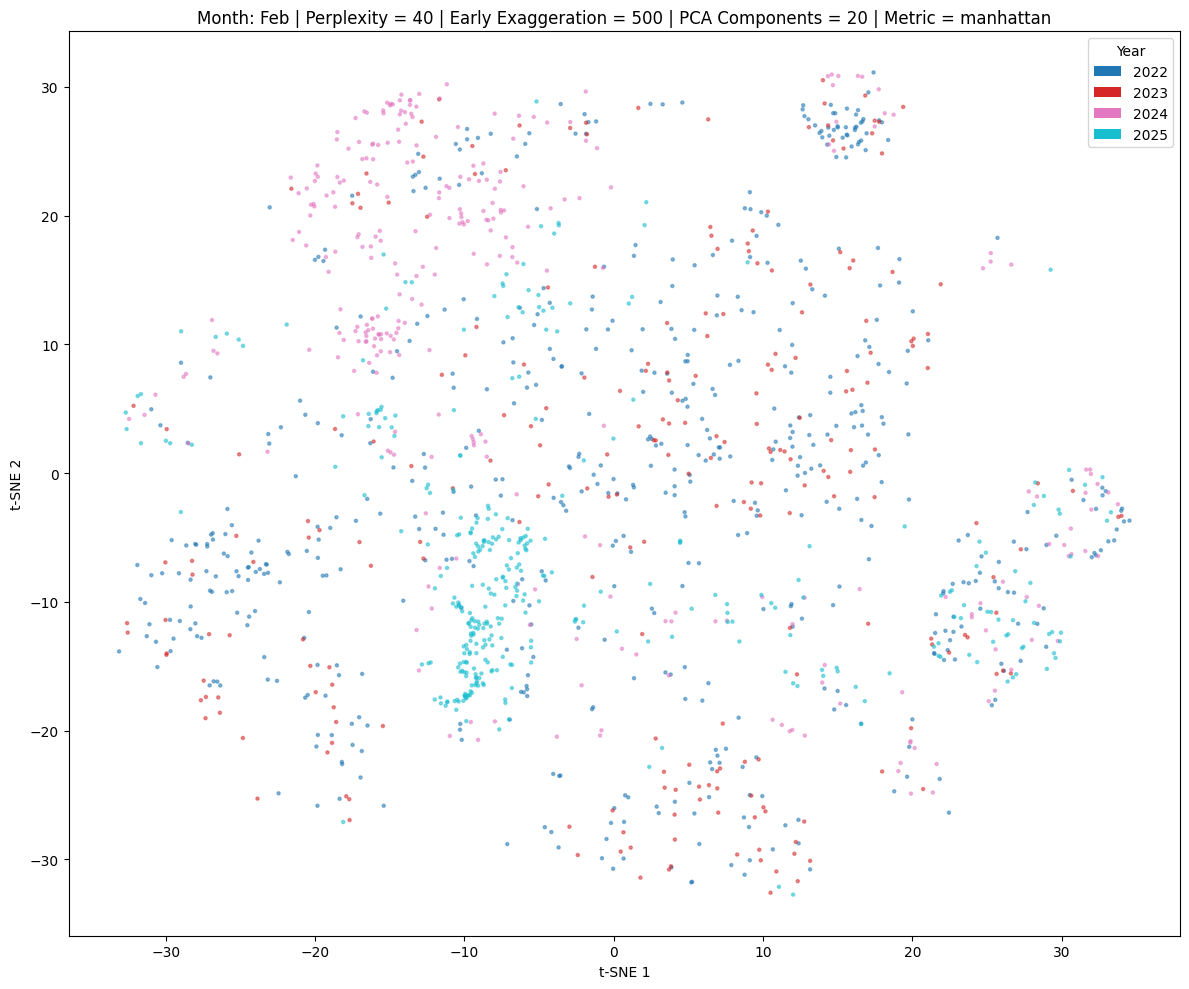

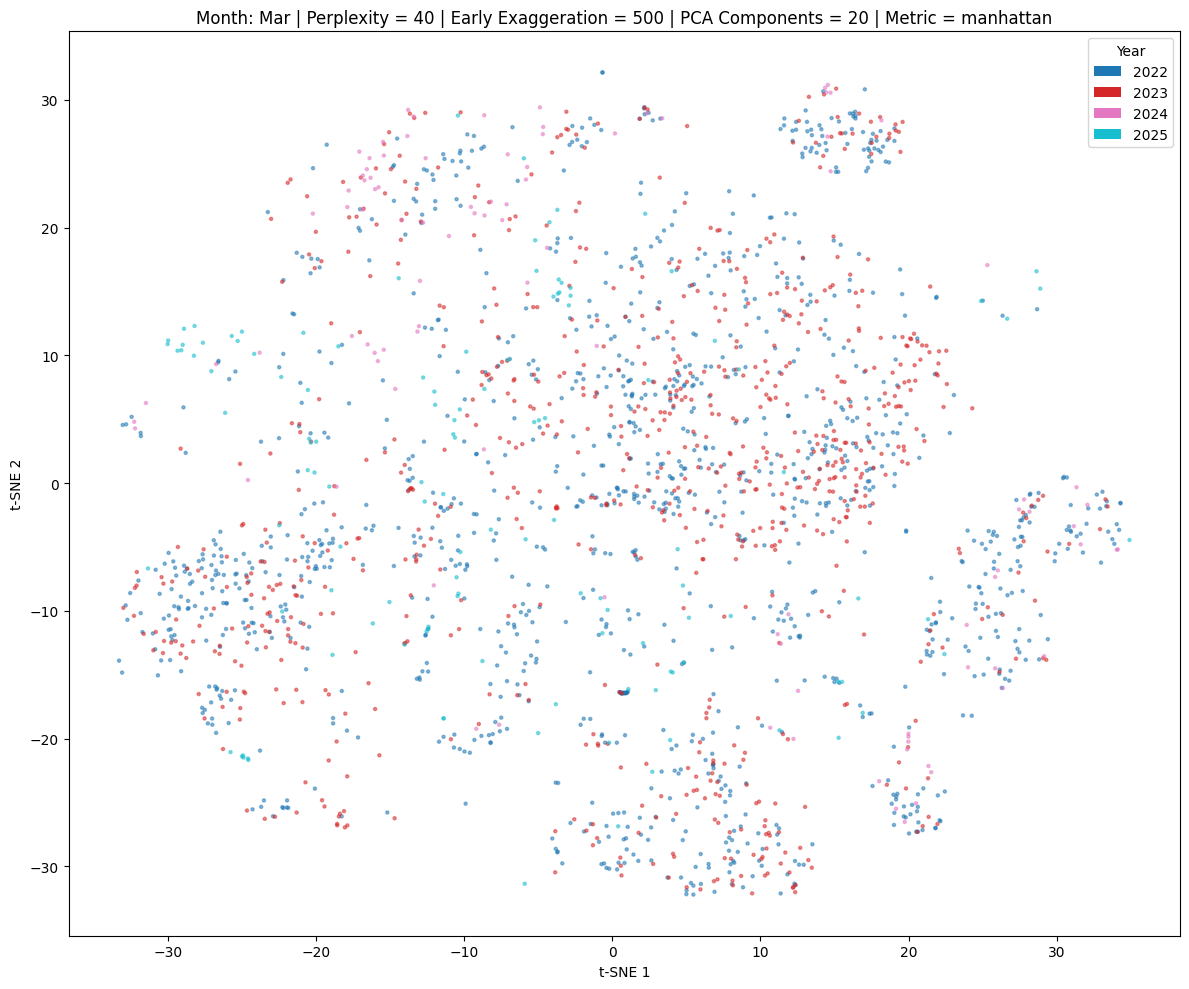

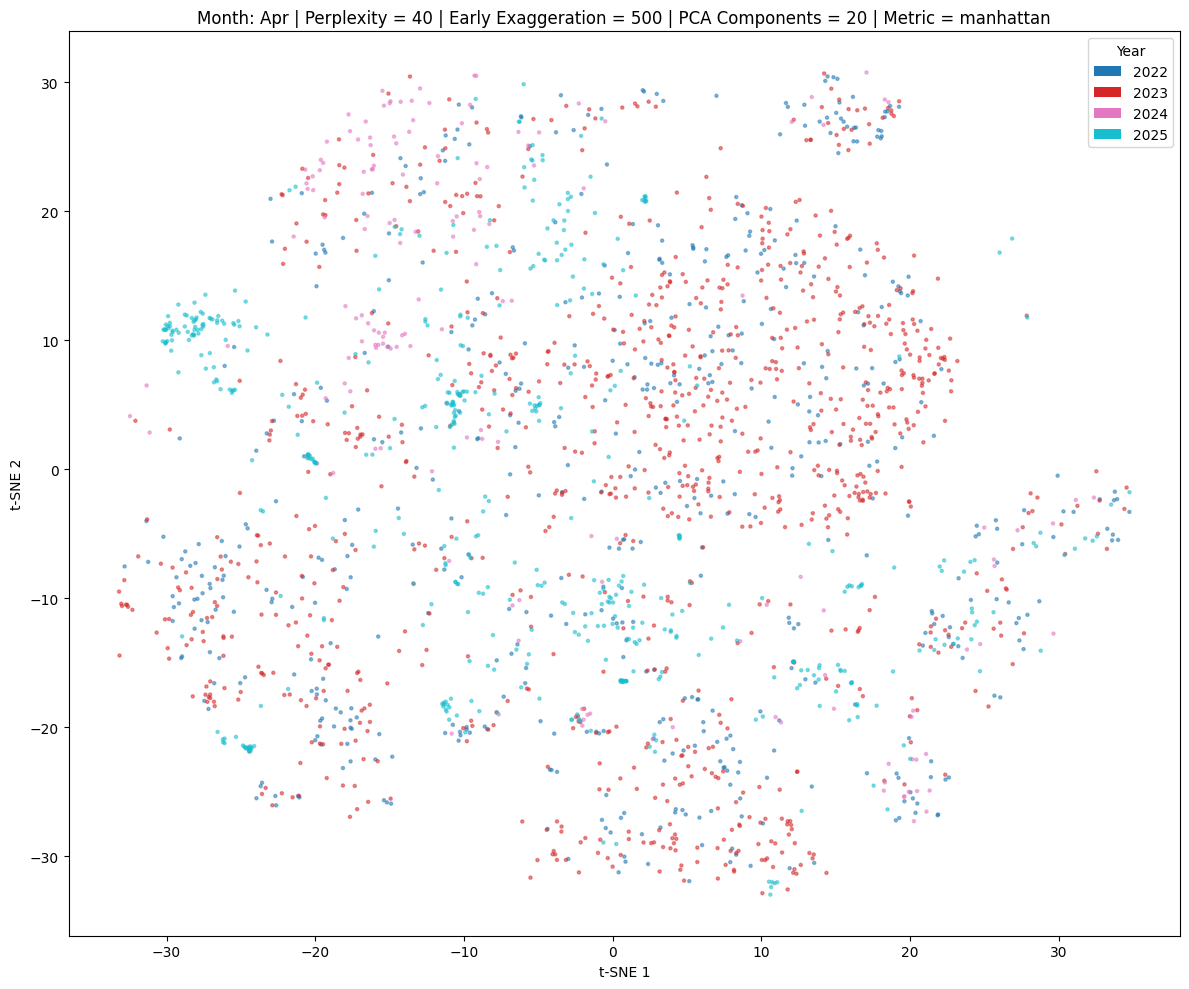

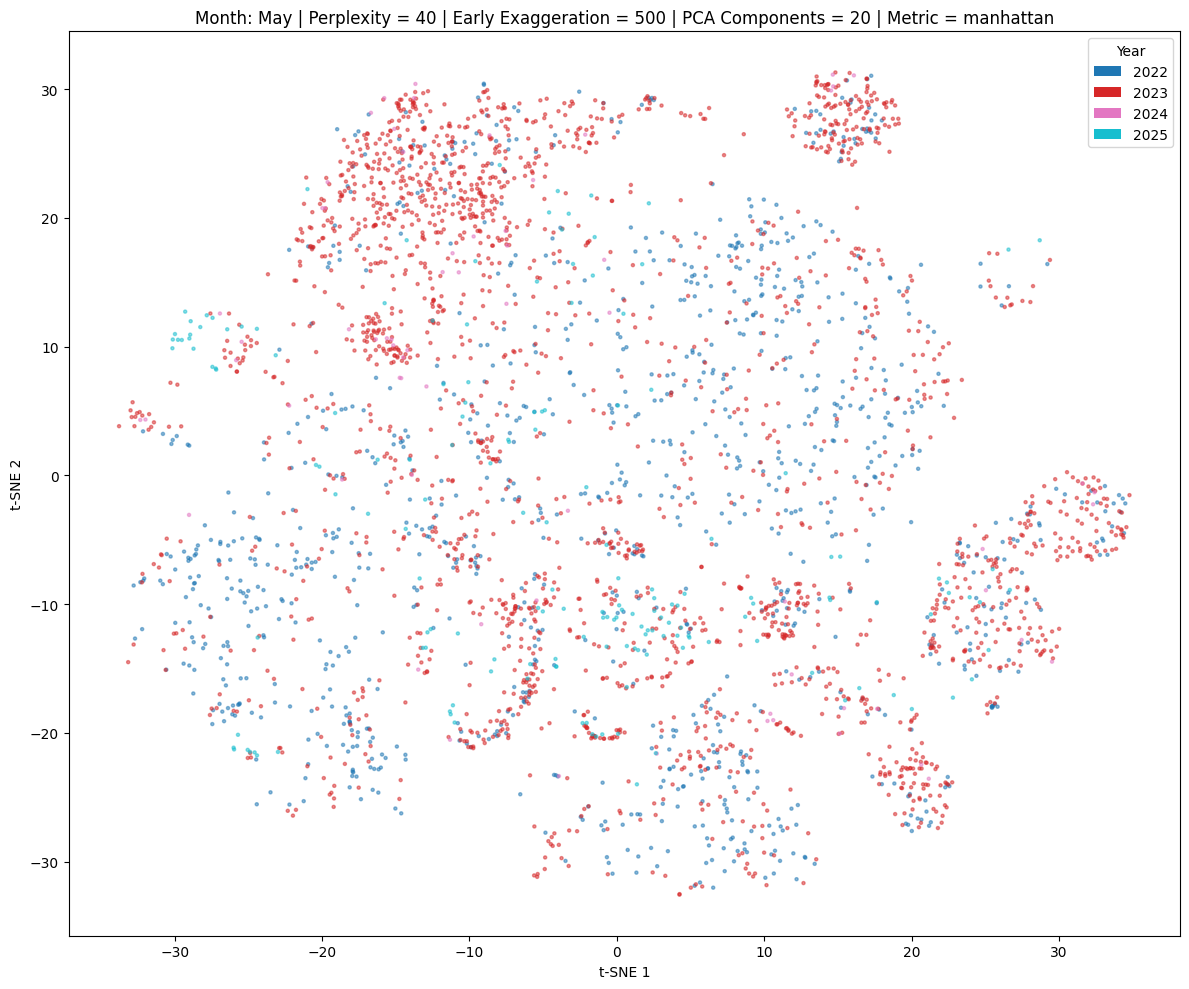

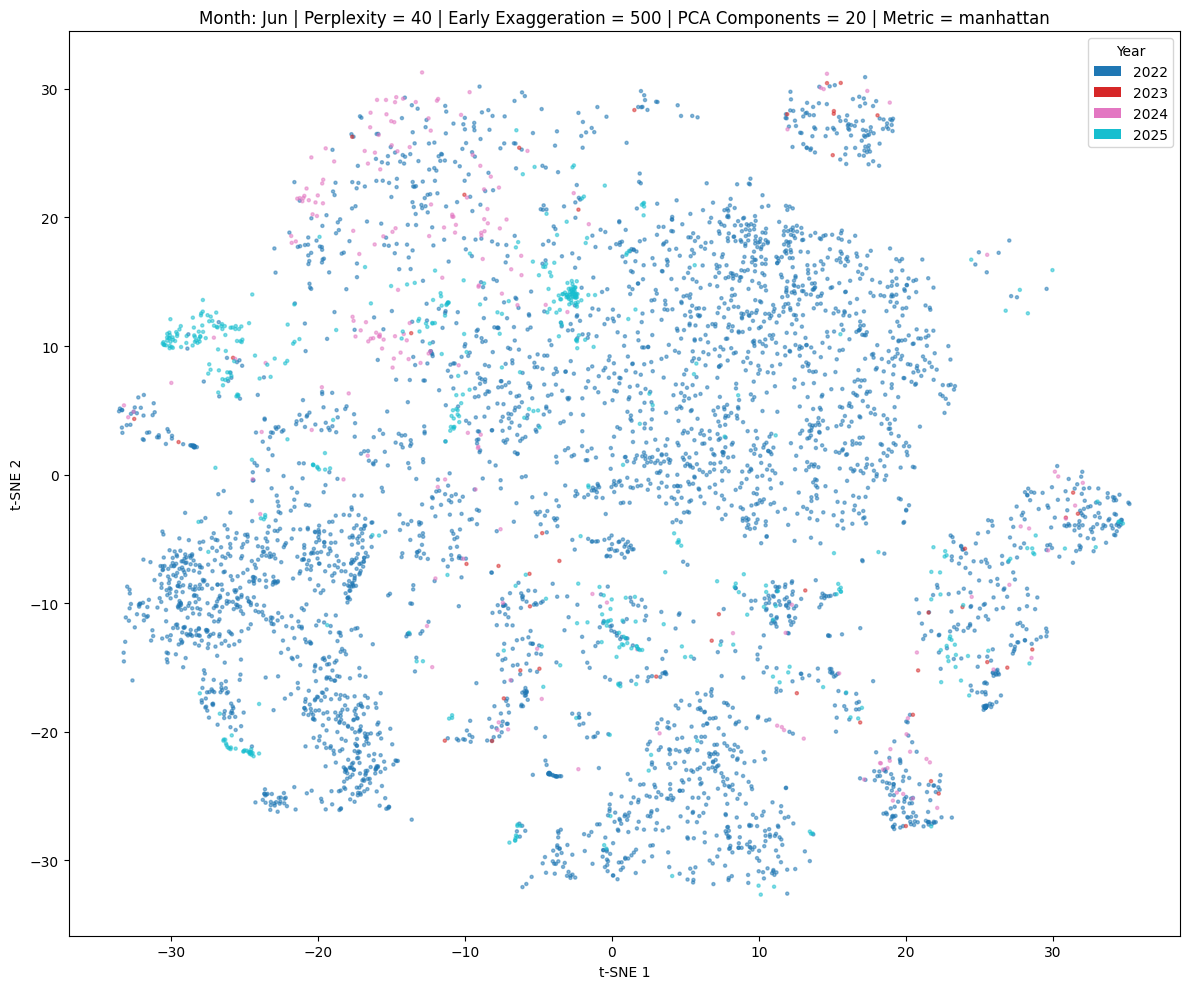

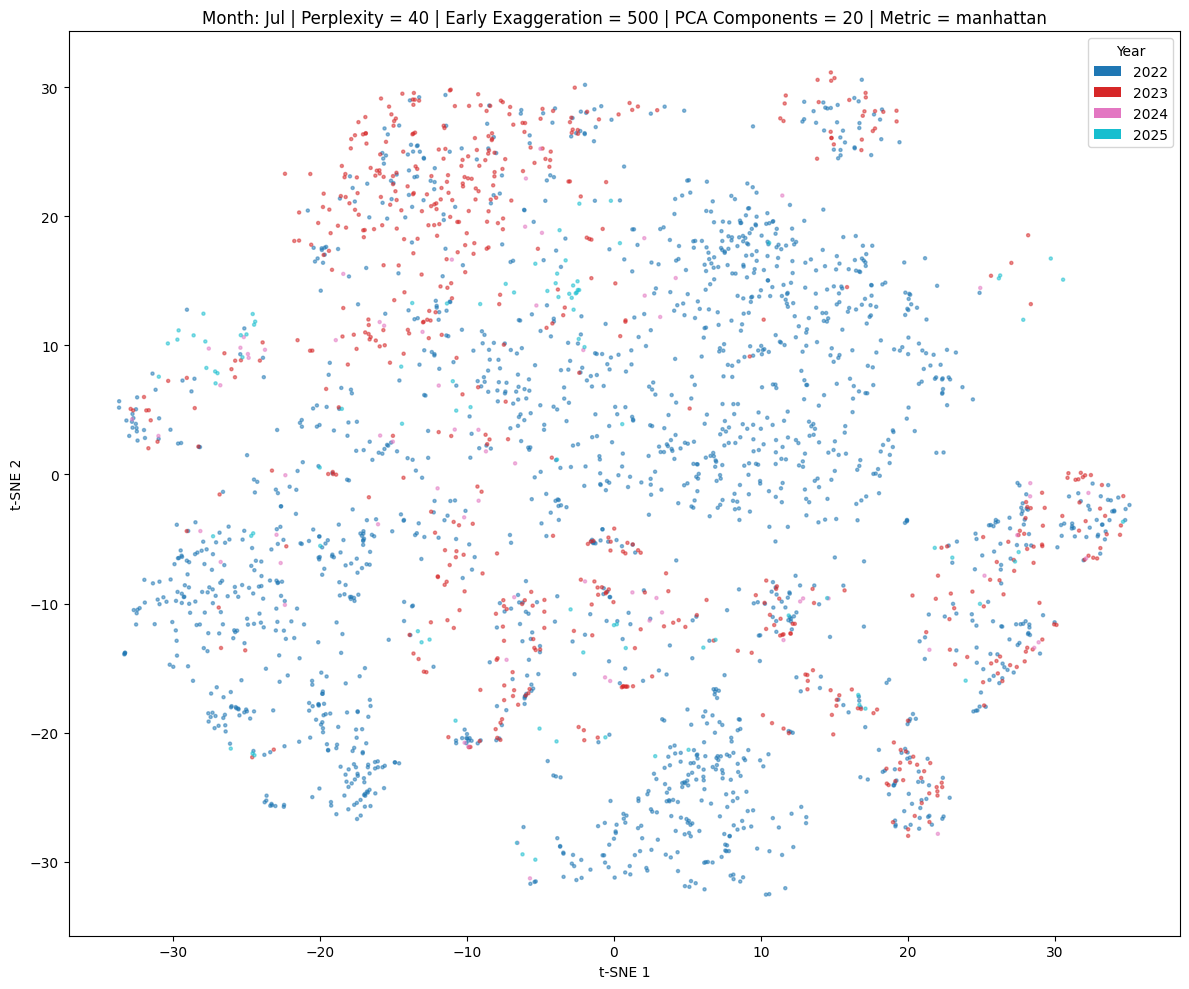

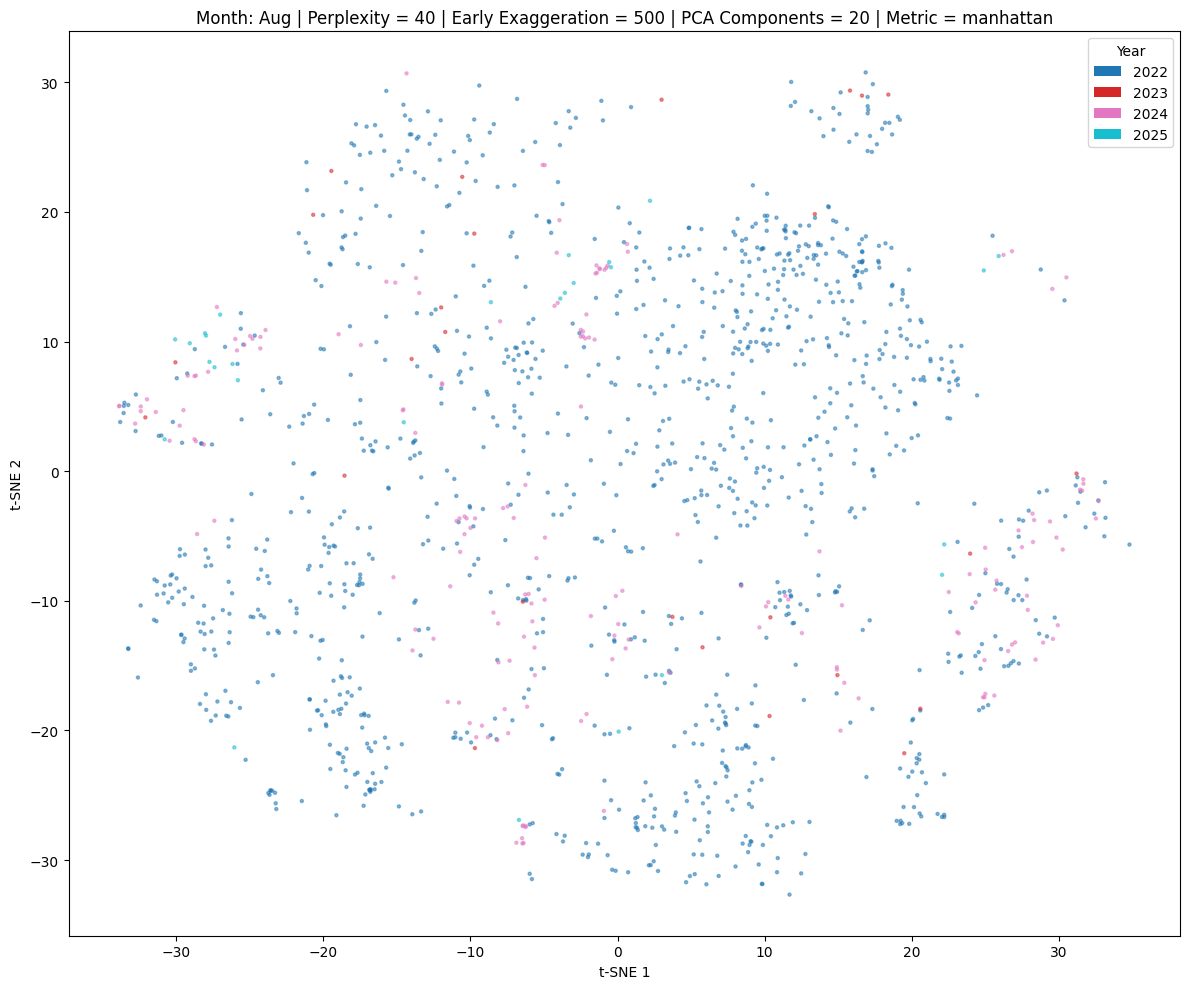

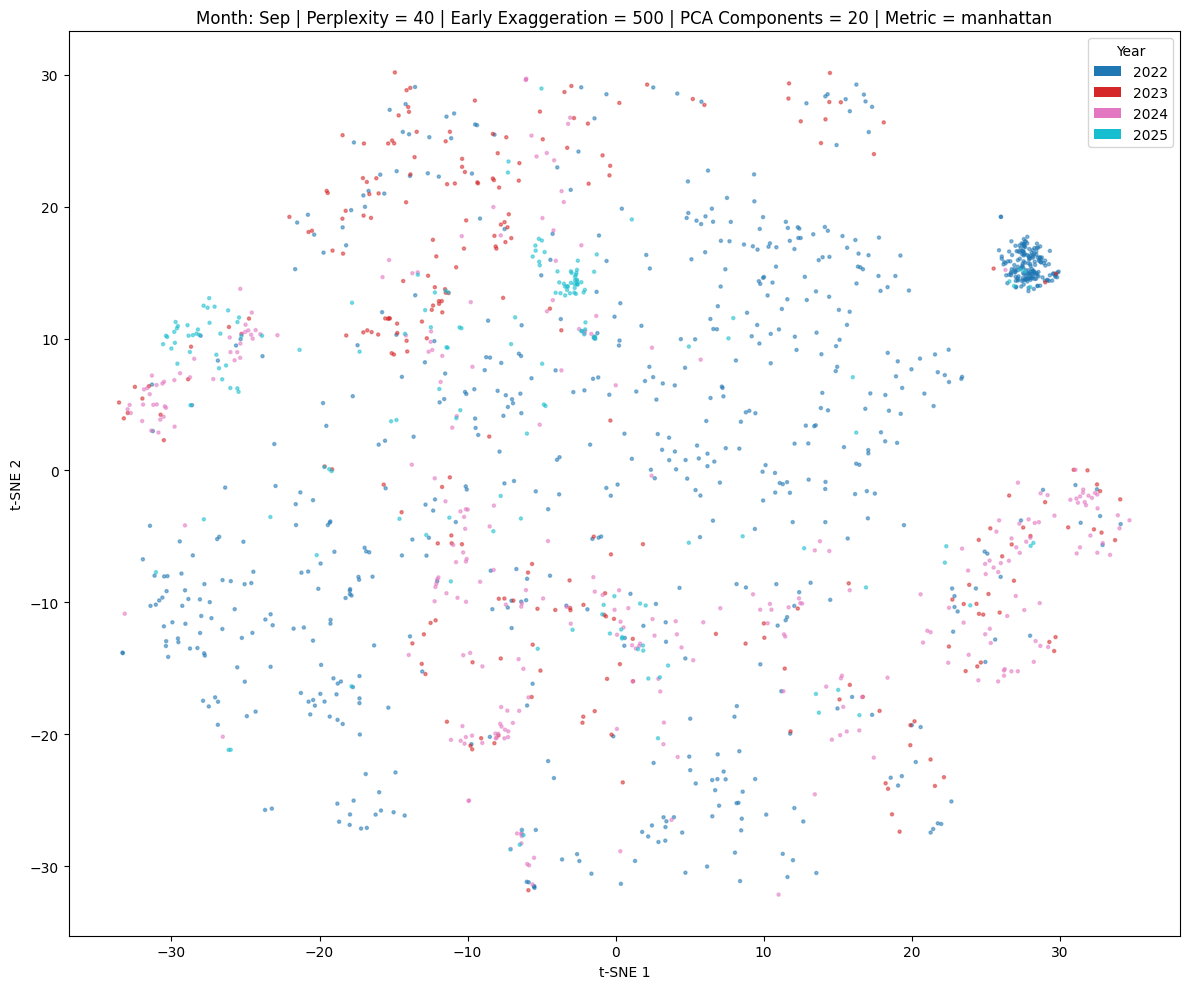

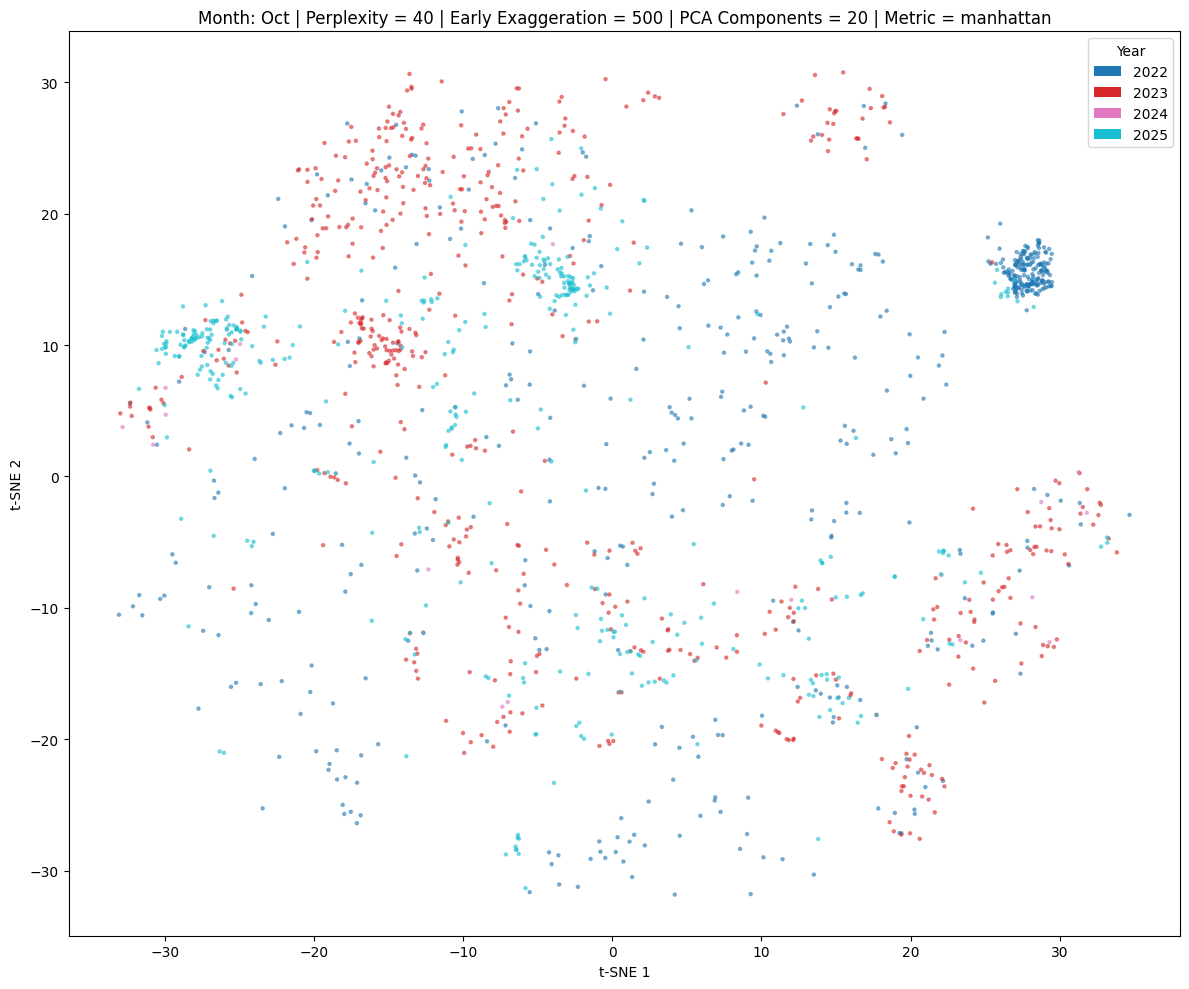

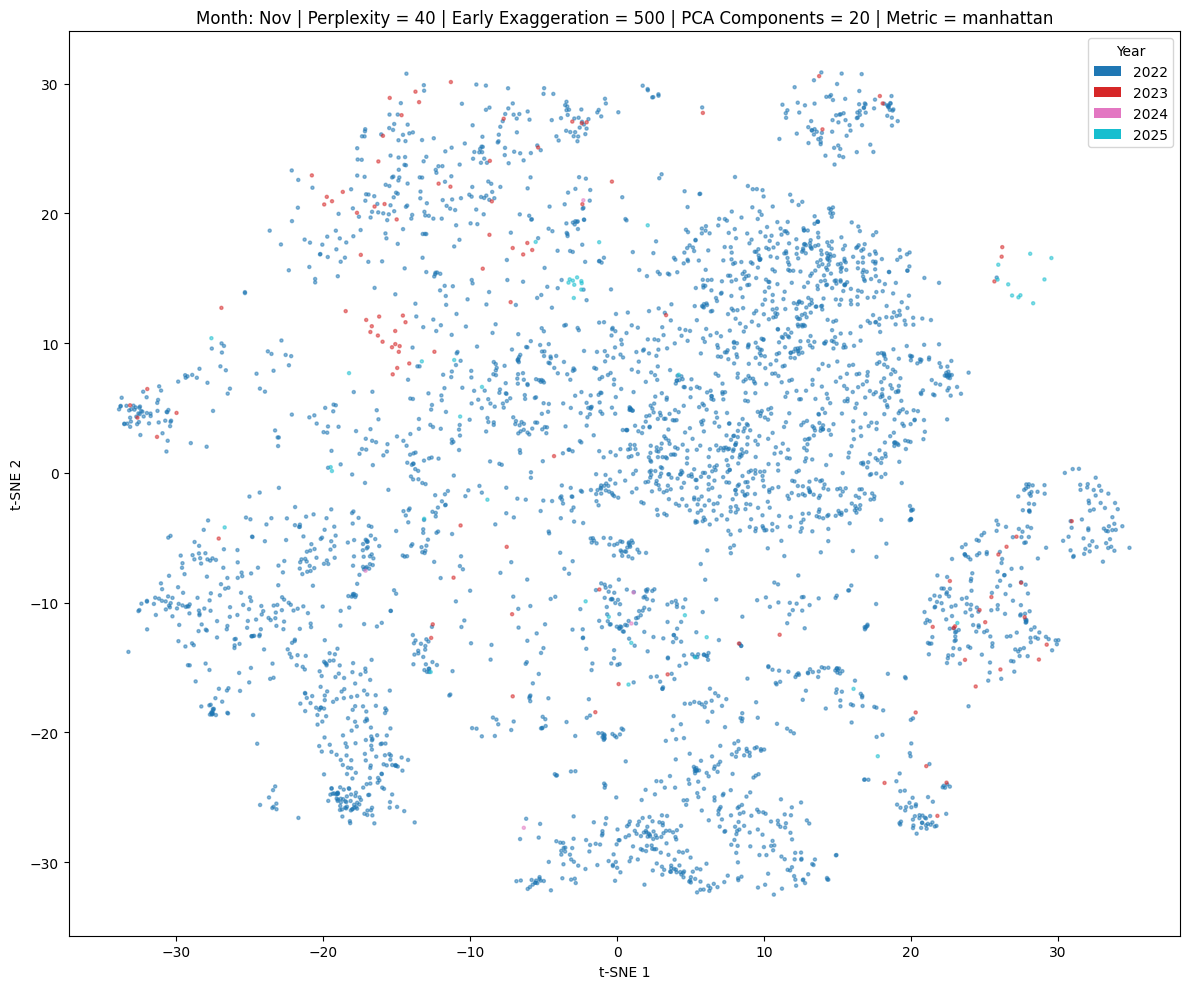

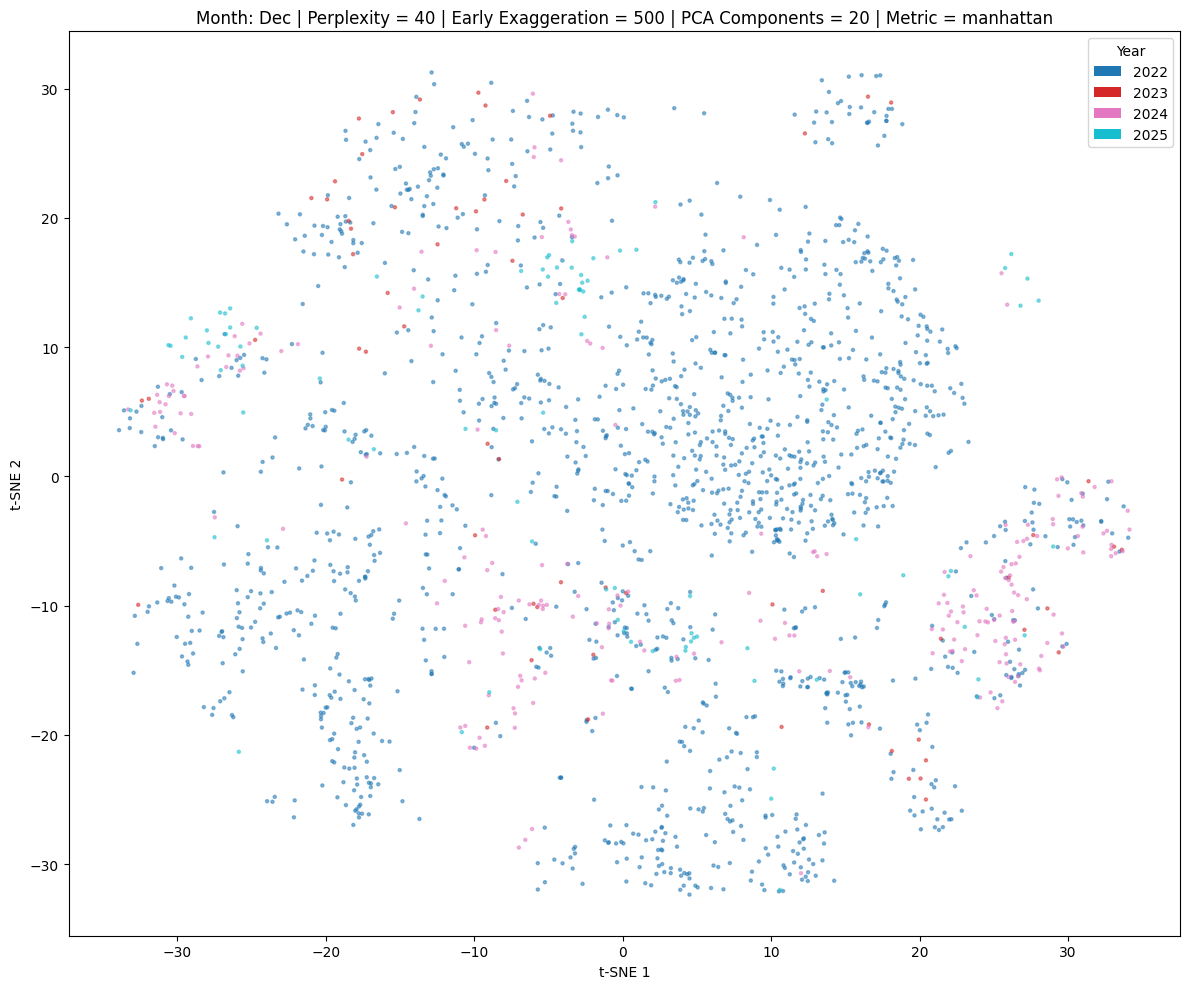

In [21]:
for month in MONTHS:
    month_mask = df_all["month"] == month
    X_tsne_month = X_tsne[month_mask]
    year_indices_month = year_indices[month_mask]

    cmap = plt.get_cmap("tab10", len(years))
    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(X_tsne_month[:, 0],X_tsne_month[:, 1],c=year_indices_month,cmap=cmap,vmin=-0.5,vmax=len(years) - 0.5,s=5,alpha=0.5)

    legend_handles = [Patch(facecolor=cmap(i), label=str(year))for i, year in enumerate(years)]
    ax.legend(handles=legend_handles,title="Year",loc="best",markerscale=2)
    ax.set_title(f"Month: {MONTH_NAMES[month]} | Perplexity = 40 | Early Exaggeration = 500 | PCA Components = {PCA_COMPONENTS} | Metric = manhattan")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()